<a href="https://colab.research.google.com/github/Samuel442/desafio-telecom-parte-2/blob/main/Desafio_Telecom_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X – Parte 2: Prevendo Churn

## 📣 História do Desafio

Parabéns! 🎉 Você foi promovido após seu excelente desempenho na análise exploratória da evasão de clientes na Telecom X. Sua dedicação, clareza na comunicação dos dados e visão estratégica fizeram a diferença.

Agora, você foi convidado a integrar oficialmente a equipe de Machine Learning da empresa!

---

## 🎯 Missão

Sua nova missão é desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços.

A empresa quer antecipar o problema da evasão, e cabe a você construir um pipeline robusto para essa etapa inicial de modelagem.

---

## 🧠 Objetivos do Desafio

- Preparar os dados para a modelagem (tratamento, encoding, normalização).
- Realizar análise de correlação e seleção de variáveis.
- Treinar dois ou mais modelos de classificação.
- Avaliar o desempenho dos modelos com métricas.
- Interpretar os resultados, incluindo a importância das variáveis.
- Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

---

## 🧰 O que você vai praticar

✅ Pré-processamento de dados para Machine Learning  
✅ Construção e avaliação de modelos preditivos  
✅ Interpretação dos resultados e entrega de insights  
✅ Comunicação técnica com foco estratégico  

---

## 🚀 Você agora é: Analista de Machine Learning Júnior

A Telecom X está confiando na sua entrega para dar os próximos passos em direção a uma solução de inteligência preditiva eficaz. Boa sorte!

### $\color{lightskyblue}{\text{Extração do Arquivo Tratado}}$

In [154]:
import pandas as pd

df_final = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/telecom_churn_tratado.csv")

df_final.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_internet_DSL,tipo_internet_Fiber optic,tipo_internet_No,tipo_contrato_Month-to-month,tipo_contrato_One year,tipo_contrato_Two year,metodo_pagamento_Bank transfer (automatic),metodo_pagamento_Credit card (automatic),metodo_pagamento_Electronic check,metodo_pagamento_Mailed check
0,0.0,0,1,1,9,1,0,0,1,0,...,True,False,False,False,True,False,False,False,False,True
1,0.0,0,0,0,9,1,1,0,0,0,...,True,False,False,True,False,False,False,False,False,True
2,1.0,0,0,0,4,1,0,0,0,1,...,False,True,False,True,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0,0,1,1,...,False,True,False,True,False,False,False,False,True,False
4,1.0,1,1,0,3,1,0,0,0,0,...,False,True,False,True,False,False,False,False,False,True


In [155]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   evasao                                      7043 non-null   float64
 1   idoso                                       7267 non-null   int64  
 2   possui_parceiro                             7267 non-null   int64  
 3   possui_dependentes                          7267 non-null   int64  
 4   tempo_contrato_meses                        7267 non-null   int64  
 5   servico_telefone                            7267 non-null   int64  
 6   multiplas_linhas                            7267 non-null   object 
 7   seguranca_online                            7267 non-null   int64  
 8   backup_online                               7267 non-null   int64  
 9   protecao_dispositivo                        7267 non-null   int64  
 10  suporte_tecn

In [156]:
df_parte2 = df_final.copy()

In [157]:
df_parte2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   evasao                                      7043 non-null   float64
 1   idoso                                       7267 non-null   int64  
 2   possui_parceiro                             7267 non-null   int64  
 3   possui_dependentes                          7267 non-null   int64  
 4   tempo_contrato_meses                        7267 non-null   int64  
 5   servico_telefone                            7267 non-null   int64  
 6   multiplas_linhas                            7267 non-null   object 
 7   seguranca_online                            7267 non-null   int64  
 8   backup_online                               7267 non-null   int64  
 9   protecao_dispositivo                        7267 non-null   int64  
 10  suporte_tecn

Pequenos ajustes

In [158]:
df_parte2 = df_parte2.dropna(subset=['evasao'])

In [159]:
df_parte2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   evasao                                      7043 non-null   float64
 1   idoso                                       7043 non-null   int64  
 2   possui_parceiro                             7043 non-null   int64  
 3   possui_dependentes                          7043 non-null   int64  
 4   tempo_contrato_meses                        7043 non-null   int64  
 5   servico_telefone                            7043 non-null   int64  
 6   multiplas_linhas                            7043 non-null   object 
 7   seguranca_online                            7043 non-null   int64  
 8   backup_online                               7043 non-null   int64  
 9   protecao_dispositivo                        7043 non-null   int64  
 10  suporte_tecnico  

In [160]:
df_parte2['cobranca_total'] = df_parte2['cobranca_total'].fillna(0)

In [161]:
df_parte2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   evasao                                      7043 non-null   float64
 1   idoso                                       7043 non-null   int64  
 2   possui_parceiro                             7043 non-null   int64  
 3   possui_dependentes                          7043 non-null   int64  
 4   tempo_contrato_meses                        7043 non-null   int64  
 5   servico_telefone                            7043 non-null   int64  
 6   multiplas_linhas                            7043 non-null   object 
 7   seguranca_online                            7043 non-null   int64  
 8   backup_online                               7043 non-null   int64  
 9   protecao_dispositivo                        7043 non-null   int64  
 10  suporte_tecnico  

In [162]:
df_parte2['multiplas_linhas'].value_counts()

,count
multiplas_linhas,
0,3390
1,2971
No phone service,682


In [163]:
df_parte2['multiplas_linhas'] = df_parte2['multiplas_linhas'].replace('No phone service', 0)

In [164]:
df_parte2['multiplas_linhas'] = df_parte2['multiplas_linhas'].astype(int)

In [165]:
df_parte2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   evasao                                      7043 non-null   float64
 1   idoso                                       7043 non-null   int64  
 2   possui_parceiro                             7043 non-null   int64  
 3   possui_dependentes                          7043 non-null   int64  
 4   tempo_contrato_meses                        7043 non-null   int64  
 5   servico_telefone                            7043 non-null   int64  
 6   multiplas_linhas                            7043 non-null   int64  
 7   seguranca_online                            7043 non-null   int64  
 8   backup_online                               7043 non-null   int64  
 9   protecao_dispositivo                        7043 non-null   int64  
 10  suporte_tecnico  

### $\color{lightskyblue}{\text{🗑️ Remoção de Colunas Irrelevantes}}$

In [166]:
df_parte2.columns

Index(['evasao', 'idoso', 'possui_parceiro', 'possui_dependentes',
       'tempo_contrato_meses', 'servico_telefone', 'multiplas_linhas',
       'seguranca_online', 'backup_online', 'protecao_dispositivo',
       'suporte_tecnico', 'streaming_tv', 'streaming_filmes', 'fatura_digital',
       'cobranca_mensal', 'cobranca_total', 'cobranca_diaria', 'genero_Female',
       'genero_Male', 'tipo_internet_DSL', 'tipo_internet_Fiber optic',
       'tipo_internet_No', 'tipo_contrato_Month-to-month',
       'tipo_contrato_One year', 'tipo_contrato_Two year',
       'metodo_pagamento_Bank transfer (automatic)',
       'metodo_pagamento_Credit card (automatic)',
       'metodo_pagamento_Electronic check', 'metodo_pagamento_Mailed check'],
      dtype='object')

As colunas já estão no padrão aceitavel pára modelos de Machine Learning

### $\color{lightskyblue}{\text{Encoding de Variáveis Categóricas}}$

In [167]:
df_parte2.head()

,evasao,idoso,possui_parceiro,possui_dependentes,tempo_contrato_meses,servico_telefone,multiplas_linhas,seguranca_online,backup_online,protecao_dispositivo,...,tipo_internet_DSL,tipo_internet_Fiber optic,tipo_internet_No,tipo_contrato_Month-to-month,tipo_contrato_One year,tipo_contrato_Two year,metodo_pagamento_Bank transfer (automatic),metodo_pagamento_Credit card (automatic),metodo_pagamento_Electronic check,metodo_pagamento_Mailed check
0,0.0,0,1,1,9,1,0,0,1,0,...,True,False,False,False,True,False,False,False,False,True
1,0.0,0,0,0,9,1,1,0,0,0,...,True,False,False,True,False,False,False,False,False,True
2,1.0,0,0,0,4,1,0,0,0,1,...,False,True,False,True,False,False,False,False,True,False
3,1.0,1,1,0,13,1,0,0,1,1,...,False,True,False,True,False,False,False,False,True,False
4,1.0,1,1,0,3,1,0,0,0,0,...,False,True,False,True,False,False,False,False,False,True


### $\color{lightskyblue}{\text{⚖️ Verificação da Proporção de Evasão}}$

In [168]:
df_parte2['evasao'].value_counts(normalize=True)

,proportion
evasao,
0.0,0.73463
1.0,0.26537


In [169]:
df_parte2['evasao'].value_counts()

,count
evasao,
0.0,5174
1.0,1869


## Verificação da Proporção de Evasão

Foi analisada a proporção de clientes que evadiram em comparação com aqueles que permaneceram ativos.

Resultados:

- Clientes que permaneceram: aproximadamente 73%
- Clientes que evadiram: aproximadamente 27%

Observa-se um leve desbalanceamento entre as classes, o que é comum em problemas de churn. No entanto, a diferença não é extrema, permitindo que modelos de Machine Learning sejam treinados sem necessidade imediata de técnicas de balanceamento.

### $\color{lightskyblue}{\text{Balanceamento de Classes (Opcional)}}$

## Balanceamento de Classes

A análise da variável alvo mostrou que aproximadamente:

- 73% dos clientes permaneceram
- 27% dos clientes evadiram

Embora exista um leve desbalanceamento, a diferença não é extrema. Portanto, optou-se inicialmente por treinar os modelos com os dados originais, avaliando posteriormente o desempenho por meio de métricas como precision, recall e F1-score.

Técnicas de balanceamento como oversampling, undersampling ou SMOTE poderiam ser aplicadas em análises futuras para investigar possíveis melhorias no desempenho do modelo.

Divisão em treino e teste

In [170]:
from sklearn.model_selection import train_test_split

X = df_parte2.drop('evasao', axis=1)
y = df_parte2['evasao']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [171]:
X_treino.shape
X_teste.shape

(2113, 28)

### $\color{lightskyblue}{\text{ Normalização ou Padronização (se necessário)}}$

In [172]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

Por que essa etapa foi feita

A normalização foi aplicada porque alguns algoritmos de machine learning são sensíveis à escala das variáveis, como Regressão Logística, KNN e SVM. Quando as variáveis possuem escalas muito diferentes (por exemplo, uma variável em dezenas e outra em milhares), isso pode influenciar negativamente o treinamento do modelo.

Ao padronizar os dados, garantimos que todas as variáveis contribuam de forma equilibrada para o modelo, melhorando o desempenho e a estabilidade do algoritmo.

Além disso, o ajuste da escala (fit) foi feito apenas nos dados de treino, enquanto os dados de teste foram apenas transformados (transform), evitando vazamento de informação entre os conjuntos.

In [173]:
X_treino_scaled[:5]

array([[-0.43781822, -0.96217527, -0.65939966, -0.75333321,  0.31499146,
        -0.85714286, -0.63227593, -0.72319785,  1.38274746, -0.64234527,
        -0.79289044, -0.80003327, -1.22474487,  0.37629515, -0.52050459,
         0.37629515, -0.98031541,  0.98031541, -0.71508233,  1.1144183 ,
        -0.52429962,  0.91141215, -0.51926571, -0.56407607, -0.53622984,
        -0.52775655,  1.41636774, -0.54061758],
       [-0.43781822, -0.96217527, -0.65939966, -1.119298  ,  0.31499146,
        -0.85714286, -0.63227593, -0.72319785,  1.38274746, -0.64234527,
         1.26120829,  1.24994802,  0.81649658,  0.16225067, -0.85755783,
         0.16225067, -0.98031541,  0.98031541,  1.39844038, -0.89732913,
        -0.52429962, -1.09719845,  1.92579633, -0.56407607, -0.53622984,
        -0.52775655, -0.70603133,  1.84973638],
       [-0.43781822,  1.03931168, -0.65939966,  0.10058464,  0.31499146,
         1.16666667, -0.63227593, -0.72319785, -0.72319785, -0.64234527,
        -0.79289044, -0.8000

### $\color{lightskyblue}{\text{🔗 Análise de Correlação}}$

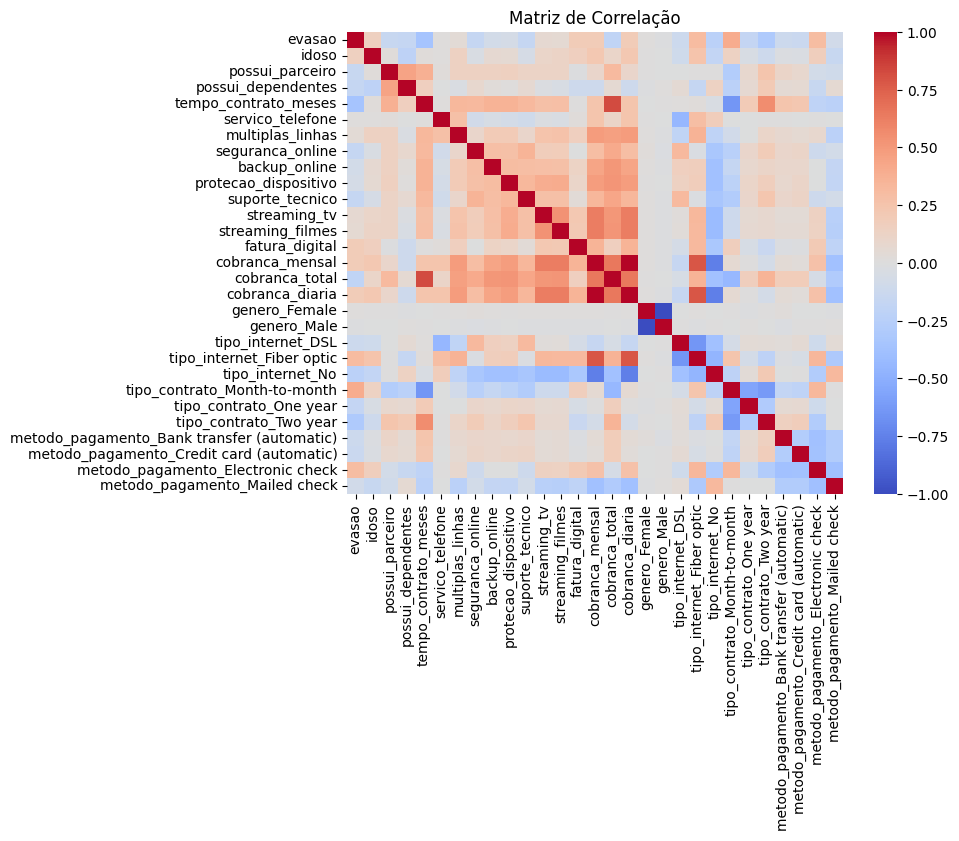

In [174]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df_parte2.corr(), cmap="coolwarm")

plt.title("Matriz de Correlação")
plt.show()

## 📊 Análise da Matriz de Correlação: Fatores de Evasão

A matriz de correlação foi utilizada para identificar relações entre as variáveis e a variável alvo **evasao**. Observou-se que algumas variáveis apresentam maior associação com o cancelamento de clientes.

### Principais Relações Identificadas:

* **`tempo_contrato_meses`**: Correlação **negativa** com evasão, indicando que clientes com mais tempo de contrato tendem a cancelar menos.
* **`tipo_contrato_Month-to-month`**: Correlação **positiva** com evasão, sugerindo maior probabilidade de cancelamento em contratos mensais.
* **`cobranca_mensal`**: Correlação **positiva** com evasão, indicando que mensalidades mais altas podem contribuir para o cancelamento.
* **Serviços adicionais** (suporte técnico, backup online e segurança online): Correlação **negativa** com evasão, sugerindo maior retenção de clientes que utilizam esses serviços.

> **Conclusão:** De modo geral, clientes com contratos curtos, mensalidades mais altas e menos serviços adicionais apresentam maior tendência à evasão.

In [175]:
df_parte2.corr()['evasao'].sort_values(ascending=False)

,evasao
evasao,1.000000
tipo_contrato_Month-to-month,0.405103
tipo_internet_Fiber optic,0.308020
metodo_pagamento_Electronic check,0.301919
cobranca_mensal,0.193356
cobranca_diaria,0.193356
fatura_digital,0.191825
idoso,0.150889
streaming_tv,0.063228
streaming_filmes,0.061382


### $\color{lightskyblue}{\text{Análises Direcionadas}}$

<Axes: xlabel='evasao', ylabel='tempo_contrato_meses'>

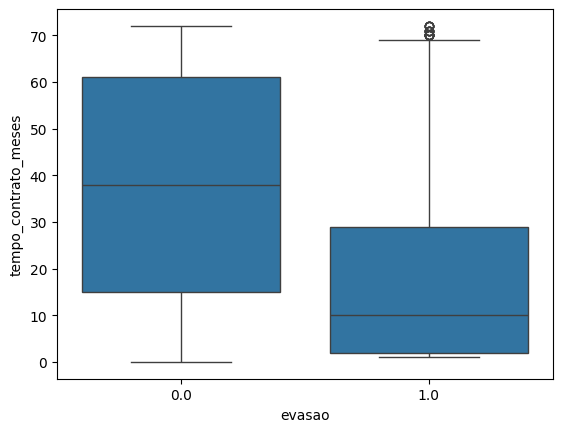

In [176]:
sns.boxplot(x='evasao', y='tempo_contrato_meses', data=df_parte2)

Tempo de contrato × Evasão
O boxplot mostra que clientes que não evadiram (0) possuem, em média, maior tempo de contrato, com a mediana bem acima dos clientes que cancelaram. Já os clientes que evadiram (1) apresentam valores concentrados em poucos meses de contrato, indicando que a evasão ocorre com maior frequência entre clientes mais recentes. Isso sugere que o tempo de relacionamento com a empresa está associado à retenção.

<Axes: xlabel='evasao', ylabel='cobranca_total'>

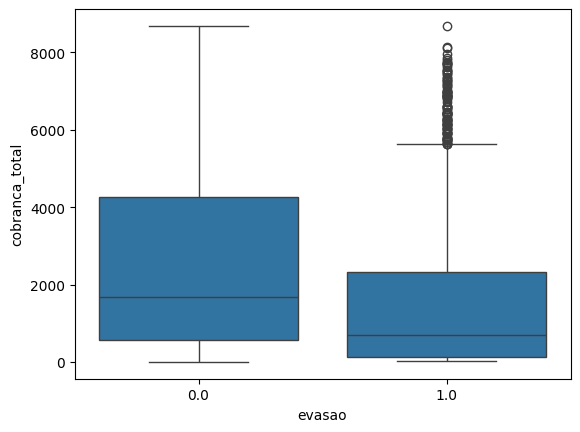

In [177]:
sns.boxplot(x='evasao', y='cobranca_total', data=df_parte2)

Cobrança total × Evasão
No gráfico de cobrança total, observa-se que clientes que permaneceram na empresa (0) apresentam valores totais pagos mais altos, enquanto os clientes que evadiram (1) concentram-se em valores menores. Esse padrão ocorre porque clientes que permanecem por mais tempo naturalmente acumulam um gasto total maior, enquanto clientes que cancelam cedo acabam apresentando valores totais mais baixos.

<Axes: xlabel='cobranca_total', ylabel='cobranca_mensal'>

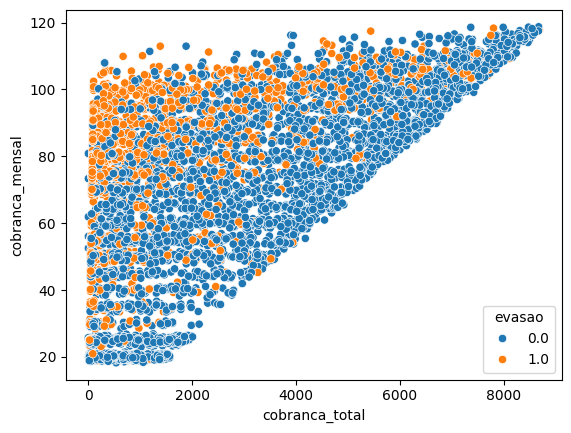

In [178]:
sns.scatterplot(x='cobranca_total', y='cobranca_mensal', hue='evasao', data=df_parte2)

Cobrança total × Cobrança mensal (dispersão)
O gráfico de dispersão mostra uma relação crescente entre cobrança mensal e cobrança total, indicando que clientes com mensalidades maiores tendem a acumular valores totais maiores ao longo do tempo. Também é possível observar que clientes que evadiram (1) aparecem com maior frequência em regiões de menor cobrança total, reforçando a ideia de que muitos cancelamentos acontecem nos primeiros períodos de contrato.

### $\color{lightskyblue}{\text{🤖 Criação de Modelos}}$

Modelo 1 — Regressão Logística

In [179]:
from sklearn.linear_model import LogisticRegression

# criando o modelo
modelo_lr = LogisticRegression(max_iter=1000)

# treinando o modelo com dados normalizados
modelo_lr.fit(X_treino_scaled, y_treino)

LogisticRegression(max_iter=1000)

Justificativa

A Regressão Logística foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, como prever se um cliente irá ou não evadir. Esse modelo funciona melhor quando as variáveis estão na mesma escala, por isso foi aplicada a normalização dos dados previamente. Além disso, é um modelo simples, eficiente e fácil de interpretar.

Modelo 2 — Random Forest

In [180]:
from sklearn.ensemble import RandomForestClassifier

# criando o modelo
modelo_rf = RandomForestClassifier(random_state=42)

# treinando o modelo (não precisa de normalização)
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier(random_state=42)

Justificativa

O Random Forest foi escolhido por ser um modelo baseado em árvores de decisão, capaz de capturar relações mais complexas entre as variáveis. Diferente de alguns algoritmos, ele não é sensível à escala dos dados, portanto não necessita de normalização. Além disso, é um modelo robusto e muito utilizado em problemas de classificação.

### $\color{lightskyblue}{\text{📊 Avaliação dos Modelos}}$

Previsões

In [181]:
# Regressão Logística
y_pred_lr = modelo_lr.predict(X_teste_scaled)

In [182]:
# Random Forest
y_pred_rf = modelo_rf.predict(X_teste)

In [183]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### $\color{lightskyblue}{\text{🔢 Calcular as Métricas}}$

In [184]:
print("Regressão Logística")

print(f"Acurácia: {accuracy_score(y_teste, y_pred_lr)*100:.2f}%")
print(f"Precisão: {precision_score(y_teste, y_pred_lr)*100:.2f}%")
print(f"Recall: {recall_score(y_teste, y_pred_lr)*100:.2f}%")
print(f"F1-score: {f1_score(y_teste, y_pred_lr)*100:.2f}%")

Regressão Logística
Acurácia: 79.84%
Precisão: 64.15%
Recall: 54.55%
F1-score: 58.96%


In [185]:
print("Random Forest")

print(f"Acurácia: {accuracy_score(y_teste, y_pred_rf)*100:.2f}%")
print(f"Precisão: {precision_score(y_teste, y_pred_rf)*100:.2f}%")
print(f"Recall: {recall_score(y_teste, y_pred_rf)*100:.2f}%")
print(f"F1-score: {f1_score(y_teste, y_pred_rf)*100:.2f}%")

Random Forest
Acurácia: 78.80%
Precisão: 62.47%
Recall: 50.45%
F1-score: 55.82%


### $\color{lightskyblue}{\text{📉 Matriz de Confusão}}$

In [186]:
from sklearn.metrics import confusion_matrix

In [187]:
# Regressão Logística
confusion_matrix(y_teste, y_pred_lr)

array([[1381,  171],
       [ 255,  306]])

In [188]:
# Random Forest
confusion_matrix(y_teste, y_pred_rf)

array([[1382,  170],
       [ 278,  283]])

In [189]:
from sklearn.metrics import classification_report

print(classification_report(y_teste, y_pred_lr))
print(classification_report(y_teste, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1552
         1.0       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1552
         1.0       0.62      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



### $\color{lightskyblue}{\text{Avaliação e Comparação dos Modelos}}$



Para avaliar o desempenho dos modelos de previsão de churn, foram utilizadas as métricas **acurácia, precisão, recall, F1-score** e **matriz de confusão**.

## Regressão Logística

A Regressão Logística apresentou **acurácia de 79,84%**, indicando que o modelo conseguiu classificar corretamente cerca de 80% dos clientes no conjunto de teste. A **precisão foi de 64,15%**, mostrando que, entre os clientes previstos como evasores, aproximadamente 64% realmente cancelaram o serviço. O **recall foi de 54,55%**, indicando que o modelo conseguiu identificar pouco mais da metade dos clientes que realmente evadiram. O **F1-score foi de 58,96%**, refletindo um equilíbrio moderado entre precisão e recall.

Na matriz de confusão, observa-se que o modelo classificou corretamente **1381 clientes que permaneceram** e **306 clientes que evadiram**, enquanto **255 evasões reais não foram identificadas**.

## Random Forest

O modelo Random Forest apresentou **acurácia de 78,80%**, um valor ligeiramente inferior ao da Regressão Logística. A **precisão foi de 62,47%**, o **recall foi de 50,45%**, e o **F1-score foi de 55,82%**. Esses valores indicam um desempenho um pouco inferior na identificação de clientes que irão cancelar.

Na matriz de confusão, o modelo classificou corretamente **1382 clientes que permaneceram** e **283 clientes que evadiram**, deixando de identificar **278 evasões reais**.

## Comparação dos Modelos

Comparando os resultados, a **Regressão Logística apresentou desempenho ligeiramente superior** em praticamente todas as métricas avaliadas, especialmente em **recall e F1-score**, que são importantes em problemas de churn, pois indicam a capacidade do modelo de identificar clientes que realmente irão cancelar.

Apesar de o Random Forest ser um modelo mais complexo e capaz de capturar relações não lineares, neste caso ele não apresentou vantagem significativa sobre o modelo mais simples.

## Overfitting e Underfitting

Com base nos resultados obtidos no conjunto de teste, **não há evidências claras de overfitting**, já que os modelos mantiveram desempenho consistente e não apresentaram métricas extremamente altas que indicariam memorização dos dados de treino.

Também não há sinais fortes de **underfitting**, pois ambos os modelos conseguem capturar padrões relevantes do conjunto de dados, alcançando aproximadamente 79–80% de acurácia.

No entanto, o **recall moderado** sugere que ainda existe espaço para melhorias, especialmente na identificação de clientes que realmente irão cancelar. Possíveis melhorias futuras incluem ajuste de hiperparâmetros, teste de novos algoritmos ou aplicação de técnicas de balanceamento de classes.

Regressão Logística (coeficientes)

In [190]:
import pandas as pd

coeficientes = pd.DataFrame({
    'Variavel': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

coeficientes

,Variavel,Coeficiente
14,cobranca_total,0.728356
19,tipo_internet_Fiber optic,0.523036
21,tipo_contrato_Month-to-month,0.305687
12,fatura_digital,0.202228
10,streaming_tv,0.181642
5,multiplas_linhas,0.169785
11,streaming_filmes,0.161568
26,metodo_pagamento_Electronic check,0.128718
0,idoso,0.062610
8,protecao_dispositivo,0.031208


Random Forest (feature importance)

In [191]:
import pandas as pd

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by='Importancia', ascending=False)

importancias

,Variavel,Importancia
14,cobranca_total,0.160034
3,tempo_contrato_meses,0.137023
13,cobranca_mensal,0.130672
15,cobranca_diaria,0.128835
21,tipo_contrato_Month-to-month,0.065095
26,metodo_pagamento_Electronic check,0.031729
19,tipo_internet_Fiber optic,0.030619
12,fatura_digital,0.023805
23,tipo_contrato_Two year,0.021505
1,possui_parceiro,0.020661


# Análise de Importância das Variáveis

Após o treinamento dos modelos, foi realizada uma análise para identificar quais variáveis possuem maior impacto na previsão de evasão de clientes. Essa análise foi conduzida utilizando dois modelos: **Regressão Logística** e **Random Forest**.

## Importância das Variáveis no Random Forest

No modelo Random Forest, a importância das variáveis é calculada com base em quanto cada variável contribui para reduzir a impureza durante as divisões das árvores de decisão.

Os resultados indicam que as variáveis mais relevantes para prever a evasão foram:

- **cobranca_total**
- **tempo_contrato_meses**
- **cobranca_mensal**
- **cobranca_diaria**
- **tipo_contrato_Month-to-month**

Isso indica que fatores financeiros e o tipo de contrato têm grande influência no comportamento de churn. Clientes com contratos mensais (Month-to-month) tendem a apresentar maior probabilidade de evasão, pois possuem maior flexibilidade para cancelar o serviço.

Além disso, variáveis relacionadas ao valor pago pelos serviços também aparecem entre as mais importantes, indicando que o custo do serviço pode influenciar diretamente a decisão de permanência ou cancelamento.

## Importância das Variáveis na Regressão Logística

Na Regressão Logística, a relevância das variáveis é analisada por meio dos **coeficientes do modelo**.

Coeficientes **positivos** indicam aumento na probabilidade de evasão, enquanto coeficientes **negativos** indicam redução na probabilidade de churn.

Entre as variáveis que **mais aumentam a probabilidade de evasão**, destacam-se:

- **cobranca_total**
- **tipo_internet_Fiber optic**
- **tipo_contrato_Month-to-month**
- **fatura_digital**

Isso sugere que clientes com internet de fibra óptica e contratos mensais podem apresentar maior tendência a cancelar o serviço, possivelmente devido a expectativas mais altas em relação ao serviço ou maior facilidade de troca de provedor.

Por outro lado, as variáveis que **mais reduzem a probabilidade de evasão** foram:

- **tempo_contrato_meses**
- **tipo_contrato_Two year**
- **tipo_internet_No**
- **cobranca_mensal**

O **tempo de contrato** apresentou o coeficiente negativo mais forte, indicando que quanto mais tempo o cliente permanece com a empresa, menor é a probabilidade de evasão.

## Conclusão da Análise

A análise dos dois modelos revela padrões consistentes sobre os fatores que influenciam o churn de clientes.

De forma geral, **clientes com contratos mensais, valores de cobrança elevados e menor tempo de permanência na empresa apresentam maior probabilidade de evasão**. Por outro lado, clientes com contratos mais longos e maior tempo de relacionamento com a empresa tendem a permanecer no serviço.

Esses resultados podem auxiliar a empresa na definição de estratégias de retenção, como incentivos para contratos de longo prazo, melhorias na proposta de valor para clientes com maior custo mensal e ações específicas para clientes em contratos mensais, que apresentam maior risco de cancelamento.

### $\color{lightskyblue}{\text{Relatório Final}}$

# Conclusão

A partir das análises realizadas e do treinamento dos modelos de Machine Learning, foi possível identificar padrões relevantes relacionados à evasão de clientes (churn).

Entre os modelos avaliados, **a Regressão Logística apresentou desempenho ligeiramente superior ao Random Forest**, alcançando melhores resultados nas métricas de acurácia, precisão, recall e F1-score. Isso indica que o modelo conseguiu identificar com maior eficiência os clientes com maior probabilidade de cancelamento.

A análise de importância das variáveis também revelou fatores importantes que influenciam diretamente a evasão de clientes.

Entre os fatores **mais associados ao aumento do churn**, destacam-se:

- **Contratos do tipo Month-to-month (mensais)**  
- **Valores de cobrança elevados (cobrança total, mensal e diária)**  
- **Uso de internet Fiber optic**  
- **Pagamento via Electronic Check**  
- **Clientes com fatura digital**

Esses fatores indicam que clientes com contratos mais flexíveis e menor compromisso de longo prazo possuem maior tendência a cancelar o serviço.

Por outro lado, algumas variáveis apresentaram **impacto negativo na evasão**, ou seja, estão associadas à permanência do cliente na empresa:

- **Maior tempo de contrato com a empresa**
- **Contratos de longo prazo (One year e Two year)**
- **Presença de serviços adicionais como suporte técnico e segurança online**

Esses resultados indicam que quanto maior o relacionamento do cliente com a empresa e quanto maior o vínculo contratual, menor é a probabilidade de evasão.

## Estratégias de Retenção

Com base nos resultados obtidos, algumas estratégias podem ser propostas para reduzir a evasão de clientes:

**1. Incentivar contratos de longo prazo**  
Oferecer benefícios ou descontos para clientes que optarem por contratos anuais ou de dois anos pode reduzir a taxa de churn.

**2. Monitorar clientes com contratos mensais**  
Clientes com contratos do tipo Month-to-month devem receber atenção especial, pois apresentam maior probabilidade de cancelamento.

**3. Avaliar a percepção de valor do serviço**  
Como as variáveis relacionadas à cobrança aparecem entre as mais relevantes, pode ser interessante avaliar se o custo do serviço está alinhado com a percepção de valor dos clientes.

**4. Fortalecer serviços adicionais**  
Serviços como suporte técnico, segurança online e backup podem aumentar o valor percebido pelo cliente e contribuir para sua permanência.

## Considerações Finais

Os resultados obtidos demonstram que técnicas de Machine Learning podem ser utilizadas com sucesso para identificar padrões de comportamento relacionados à evasão de clientes. A análise dos modelos e das variáveis mais relevantes permite não apenas prever o churn, mas também gerar **insights estratégicos que auxiliam na tomada de decisão e na definição de políticas de retenção de clientes**.